In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lsind18/solid-waste-and-recycling-collection-routes")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dhanshree_Sarode\.cache\kagglehub\datasets\lsind18\solid-waste-and-recycling-collection-routes\versions\1


In [5]:
import os
import pandas as pd

# check files inside the downloaded folder
files = os.listdir(path)
print("Files in dataset:", files)

# loading CSV file
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

Files in dataset: ['solid-waste-and-recycling-collection-routes1.csv']


In [6]:
df.head()

,objectid,day,cycle,sw_pickup,rec_pickup,yw_pickup,sw_route,rec_route,yw_route,recycleschedule,geo_shape,geo_point_X,geo_point_Y,collectionday,square_miles
0,28,Thursday,Yellow,Yes,Yes,No,H177,H205_Y,NaN,NaN,"{""type"": ""MultiPolygon"", ""coordinates"": [[[[-7...",35.766990,-78.781205,Thursday,0.004633
1,29,Thursday,Yellow,Yes,No,No,H177,NaN,NaN,NaN,"{""type"": ""MultiPolygon"", ""coordinates"": [[[[-7...",35.761005,-78.781399,Thursday,0.009829
2,32,Thursday,Blue,Yes,Yes,Yes,H178,H204_B,H305,NaN,NaN,NaN,NaN,Thursday,0.100017
3,34,Thursday,Blue,Yes,Yes,Yes,H178,H208_B,H305,NaN,"{""type"": ""MultiPolygon"", ""coordinates"": [[[[-7...",35.695320,-78.800928,Thursday,0.096303
4,35,Thursday,Blue,Yes,Yes,No,H178,H208_B,NaN,NaN,"{""type"": ""Polygon"", ""coordinates"": [[[-78.7984...",35.694444,-78.798789,Thursday,0.002247


# Data cleaning

In [7]:
# remove duplicates
df = df.drop_duplicates()

# handle missing values
df = df.fillna(method='ffill')

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (356, 15)


C:\Users\Dhanshree_Sarode\AppData\Local\Temp\ipykernel_7536\399189499.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


# Create Synthetic Bins

In [56]:
import numpy as np

n = 500  # number of bins

bins = pd.DataFrame({
    "bin_id": range(n),
    "lat": np.random.uniform(19.9, 20.1, n),
    "lon": np.random.uniform(73.7, 74.0, n),
    "fill_level": np.random.randint(20, 100, n)
})


In [ ]:
bins["day"] = np.random.randint(1, 7, n)
bins["zone"] = np.random.randint(1, 5, n)
bins["prev_fill"] = np.random.randint(20, 80, n)
bins["population_density"] = np.random.randint(100, 1000, n)

#create relationship
bins["fill_level"] = (
    0.6 * bins["prev_fill"] +
    1.5 * bins["day"] +
    2.5 * bins["zone"] +
    0.01 * bins["population_density"] +
    np.random.normal(0, 5, n)
).clip(0, 100)

In [46]:
print(bins.head())

   bin_id        lat        lon  fill_level  day  prev_fill  zone  \
0       0  19.930252  73.939396   39.405711    4         53     3   
1       1  19.973380  73.720446   47.629251    5         46     3   
2       2  20.003099  73.908928   39.710083    4         35     2   
3       3  20.042479  73.858418   57.609328    4         55     4   
4       4  19.992812  73.794492   64.937164    6         70     3   

   predicted_fill  population_density  
0       66.412024                 318  
1       50.065886                 291  
2       69.573533                 637  
3       59.636922                 600  
4       67.679128                 891  


#### Feature Engineering

In [9]:
bins["day"] = np.random.randint(1, 7, n)
bins["prev_fill"] = np.random.randint(10, 90, n)
bins["zone"] = np.random.randint(1, 5, n)

# Machine learning

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

In [37]:
X = bins[["day", "zone", "prev_fill", "population_density"]]
y = bins["fill_level"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [50]:
pred = model.predict(X_test)

#### evaluation

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.7647213851936161
MAE: 4.512546758745759
RMSE: 5.616004458202441


#### selection of bins

In [32]:
import numpy as np
df["fill_level"]: np.random.randint(20, 100, n)

In [33]:
bins["predicted_fill"] = model.predict(X)

selected_bins = bins[bins["predicted_fill"] > 70]

print("Selected bins:", selected_bins.shape)

Selected bins: (89, 9)


# Route optimization

In [34]:
import networkx as nx
from scipy.spatial import distance_matrix

coords = selected_bins[["lat", "lon"]].values

dist_matrix = distance_matrix(coords, coords)

G = nx.Graph()

for i in range(len(coords)):
    for j in range(len(coords)):
        if i != j:
            G.add_edge(i, j, weight=dist_matrix[i][j])

route = nx.approximation.traveling_salesman_problem(G, weight='weight')

print("Optimized Route:", route)

Optimized Route: [0, 64, 43, 20, 29, 88, 68, 34, 44, 56, 84, 59, 8, 25, 10, 47, 50, 71, 38, 40, 78, 76, 13, 83, 32, 23, 37, 11, 61, 75, 55, 27, 42, 48, 80, 18, 63, 6, 73, 15, 77, 17, 5, 49, 30, 2, 28, 16, 24, 70, 69, 82, 67, 14, 54, 87, 36, 41, 60, 86, 74, 22, 72, 52, 21, 66, 9, 12, 33, 39, 57, 46, 19, 4, 85, 45, 62, 81, 1, 31, 7, 35, 51, 79, 53, 3, 58, 26, 65, 0]


# Visualization

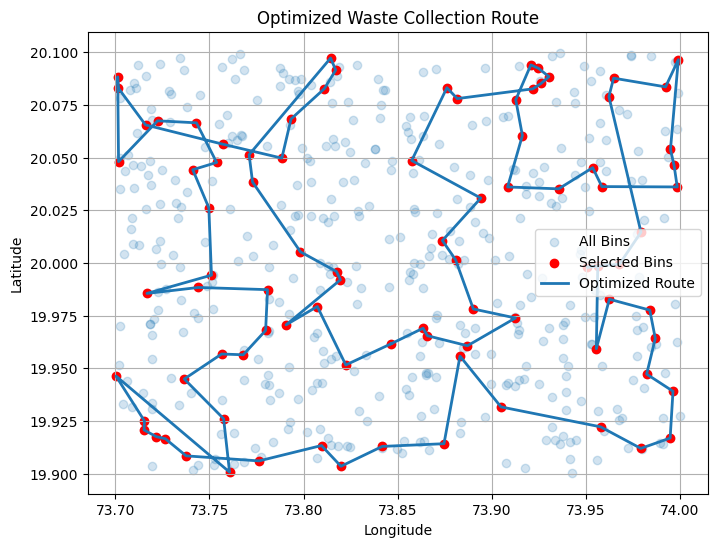

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(bins["lon"], bins["lat"], alpha=0.2, label="All Bins")
plt.scatter(selected_bins["lon"], selected_bins["lat"], color='red', label="Selected Bins")

route_coords = coords[route]
plt.plot(route_coords[:,1], route_coords[:,0], linewidth=2, label="Optimized Route")

plt.title("Optimized Waste Collection Route")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid()

plt.show()

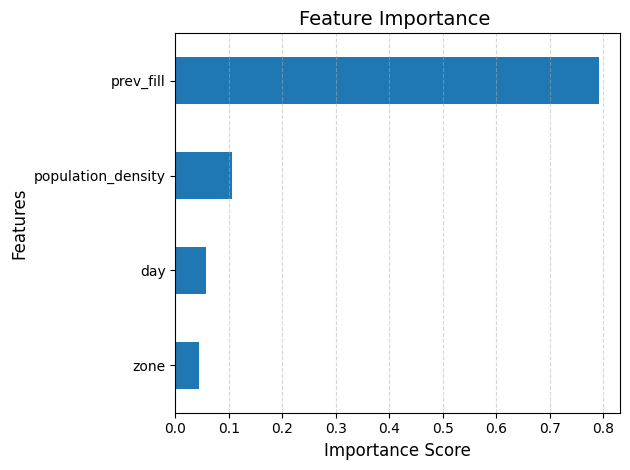

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title="Feature Importance")
plt.title("Feature Importance ", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.show()